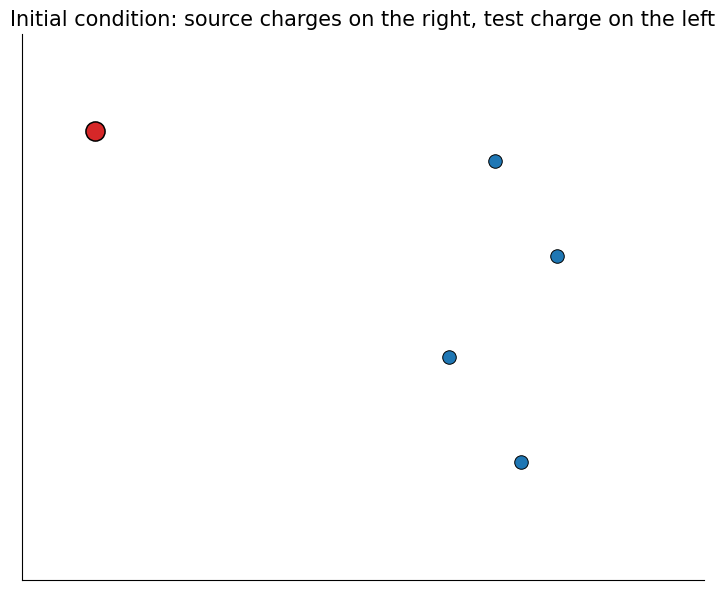

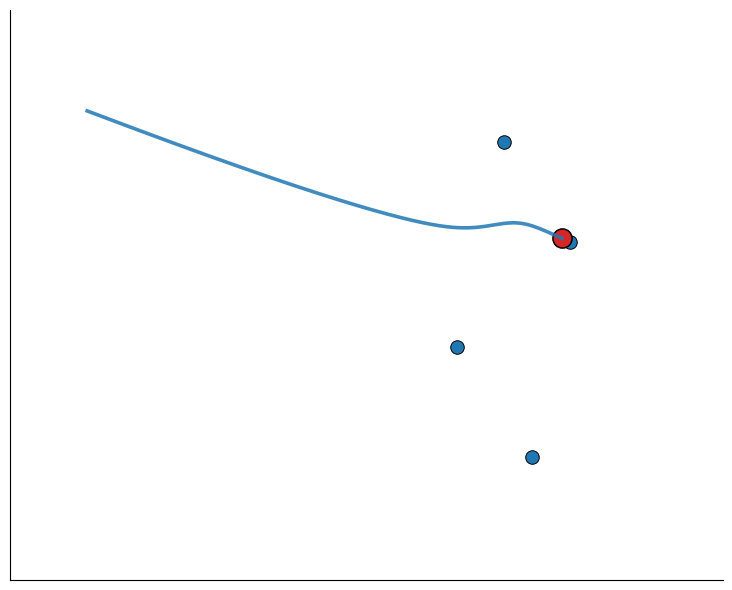

Number of source charges: 4
Number of simulated steps: 750
Initial position: [-2.35  1.55]
Final position:   [1.64887163 0.47735244]
Saved initial condition image to: slide2_initial_condition.png
Saved animation GIF to: slide2_charge_motion.gif


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ============================================================
# Slide 2 simulation:
# Fixed negative source charges are placed on the right.
# A positive test charge starts on the left and moves toward them
# in a viscous / overdamped medium.
#
# Dynamics:
#   dx/dt = mobility * F(x)
#
# Discretized:
#   x_{t+1} = x_t + dt * mobility * F(x_t)
#
# Important:
# This is NOT Newtonian acceleration.
# We use overdamped motion because later diffusion dynamics
# will also be first-order dynamics.
# ============================================================


# -----------------------------
# 1. Tunable settings
# -----------------------------
np.random.seed(7)

N_SOURCE_CHARGES = 4          # tune this number
SOURCE_SHAPE = "S"             # "S" or "triangle"

DT = 0.015
N_STEPS = 1200
MOBILITY = 0.55
K_COULOMB = 1.0
SOFTENING = 0.14
MAX_SPEED = 2.0

CAPTURE_RADIUS = 0.08

X_LIM = (-3.0, 3.0)
Y_LIM = (-2.4, 2.4)

SOURCE_CENTER = np.array([1.25, 0.0])
START_POS = np.array([-2.35, 1.55])

SAVE_INITIAL_PNG = True
SAVE_ANIMATION_GIF = True

INITIAL_PNG_PATH = "slide2_initial_condition.png"
ANIMATION_GIF_PATH = "slide2_charge_motion.gif"


# -----------------------------
# 2. Build fixed negative charges
# -----------------------------
def make_source_charges(shape="S", n=18, center=np.array([1.25, 0.0])):
    """
    Return fixed negative source-charge locations as an array of shape [n, 2].
    The shape is shifted to the right using `center`.
    """

    if shape == "S":
        t = np.linspace(-np.pi, np.pi, n)

        x = 0.55 * np.sin(1.05 * t)
        y = 1.35 * t / np.pi

        charges = np.stack([x, y], axis=1)
        charges += 0.035 * np.random.randn(n, 2)

    elif shape == "triangle":
        n1 = n // 3
        n2 = n // 3
        n3 = n - n1 - n2

        A = np.array([-0.65, -0.95])
        B = np.array([0.65, -0.95])
        C = np.array([0.0, 0.95])

        edge1 = np.linspace(A, B, n1, endpoint=False)
        edge2 = np.linspace(B, C, n2, endpoint=False)
        edge3 = np.linspace(C, A, n3, endpoint=False)

        charges = np.vstack([edge1, edge2, edge3])
        charges += 0.025 * np.random.randn(n, 2)

    else:
        raise ValueError("shape must be 'S' or 'triangle'")

    charges = charges + center[None, :]
    return charges


source_pos = make_source_charges(
    shape=SOURCE_SHAPE,
    n=N_SOURCE_CHARGES,
    center=SOURCE_CENTER
)


# -----------------------------
# 3. Force from fixed negative charges
# -----------------------------
def force_on_positive_charge(x, source_positions):
    """
    Compute the total attractive force on a positive charge at position x.

    The negative source charges are fixed.
    The positive test charge is attracted toward them.

    Softened Coulomb-like force:

        F_i = k * r_i / (|r_i|^2 + eps^2)^(3/2)

    where:

        r_i = x_source_i - x_positive
    """

    r = source_positions - x[None, :]
    dist2 = np.sum(r**2, axis=1) + SOFTENING**2
    dist3 = dist2 ** 1.5

    forces = K_COULOMB * r / dist3[:, None]
    F = np.sum(forces, axis=0)

    return F


def overdamped_step(x, source_positions, dt=DT):
    """
    One Euler step of overdamped dynamics:

        dx/dt = mobility * F(x)

    so:

        x_{t+1} = x_t + dt * mobility * F(x_t)
    """

    F = force_on_positive_charge(x, source_positions)
    v = MOBILITY * F

    speed = np.linalg.norm(v)
    if speed > MAX_SPEED:
        v = v / speed * MAX_SPEED

    x_next = x + dt * v
    return x_next


# -----------------------------
# 4. Simulate trajectory
# -----------------------------
trajectory = [START_POS.copy()]
x = START_POS.copy()

for step in range(N_STEPS):
    x_new = overdamped_step(x, source_pos, DT)
    trajectory.append(x_new.copy())
    x = x_new

    distances = np.linalg.norm(source_pos - x[None, :], axis=1)
    if np.min(distances) < CAPTURE_RADIUS:
        break

trajectory = np.array(trajectory)


# -----------------------------
# 5. Plot styling helper
# -----------------------------
def clean_axes(ax):
    """
    Remove tick numbers and keep only clean x/y axes.
    """

    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM)
    ax.set_aspect("equal")

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# -----------------------------
# 6. Static initial-condition plot
# -----------------------------
def plot_initial_condition():
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(
        source_pos[:, 0],
        source_pos[:, 1],
        s=95,
        c="tab:blue",
        edgecolor="black",
        linewidth=0.7
    )

    ax.scatter(
        START_POS[0],
        START_POS[1],
        s=190,
        c="tab:red",
        edgecolor="black",
        linewidth=1.1
    )

    ax.set_title(
        "Initial condition: source charges on the right, test charge on the left",
        fontsize=15
    )

    clean_axes(ax)

    plt.tight_layout()

    if SAVE_INITIAL_PNG:
        plt.savefig(INITIAL_PNG_PATH, dpi=300, bbox_inches="tight")

    plt.show()


plot_initial_condition()


# -----------------------------
# 7. Animation of positive charge motion
# -----------------------------
def animate_charge_motion():
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(
        source_pos[:, 0],
        source_pos[:, 1],
        s=95,
        c="tab:blue",
        edgecolor="black",
        linewidth=0.7
    )

    path_line, = ax.plot([], [], lw=2.6, alpha=0.85)

    pos_dot = ax.scatter(
        [],
        [],
        s=190,
        c="tab:red",
        edgecolor="black",
        linewidth=1.1
    )

    #ax.set_title("Overdamped motion of a positive charge", fontsize=15)

    clean_axes(ax)

    frame_ids = np.linspace(0, len(trajectory) - 1, 180).astype(int)

    def init():
        path_line.set_data([], [])
        pos_dot.set_offsets(np.array([[trajectory[0, 0], trajectory[0, 1]]]))
        return path_line, pos_dot

    def update(frame_idx):
        idx = frame_ids[frame_idx]

        path_line.set_data(
            trajectory[:idx + 1, 0],
            trajectory[:idx + 1, 1]
        )

        pos_dot.set_offsets(
            np.array([[trajectory[idx, 0], trajectory[idx, 1]]])
        )

        return path_line, pos_dot

    anim = FuncAnimation(
        fig,
        update,
        frames=len(frame_ids),
        init_func=init,
        interval=35,
        blit=True
    )

    plt.tight_layout()

    if SAVE_ANIMATION_GIF:
        anim.save(ANIMATION_GIF_PATH, writer=PillowWriter(fps=25))

    plt.show()

    return anim


anim = animate_charge_motion()


# -----------------------------
# 8. Print final information
# -----------------------------
print(f"Number of source charges: {N_SOURCE_CHARGES}")
print(f"Number of simulated steps: {len(trajectory)}")
print(f"Initial position: {trajectory[0]}")
print(f"Final position:   {trajectory[-1]}")

if SAVE_INITIAL_PNG:
    print(f"Saved initial condition image to: {INITIAL_PNG_PATH}")

if SAVE_ANIMATION_GIF:
    print(f"Saved animation GIF to: {ANIMATION_GIF_PATH}")

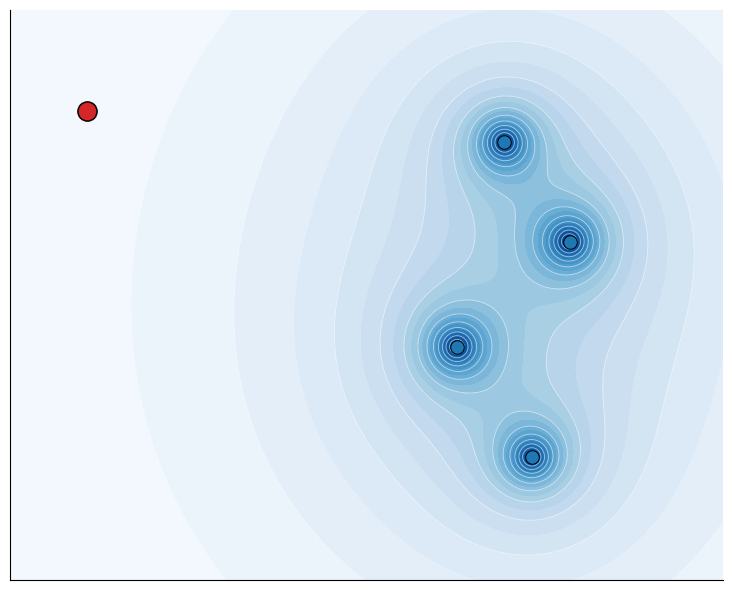

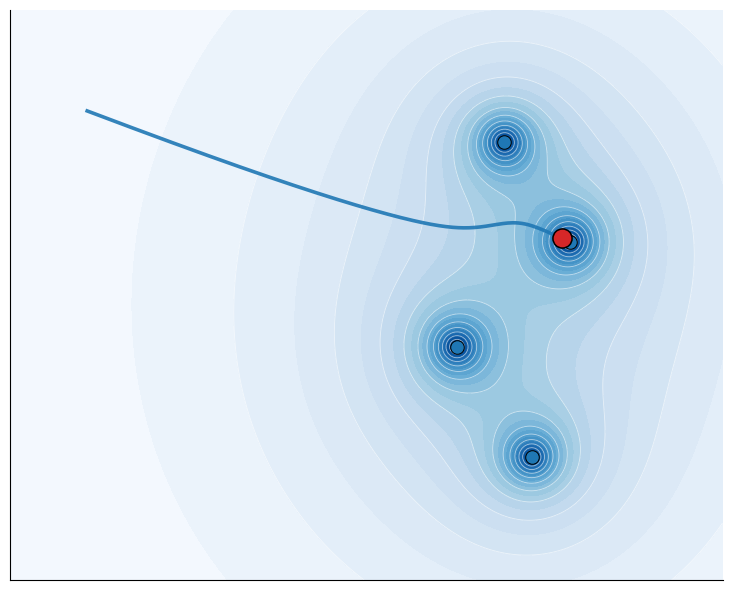

Number of source charges: 4
Number of simulated steps: 750
Initial position: [-2.35  1.55]
Final position:   [1.64887163 0.47735244]
Saved static image to: slide3_potential_initial.png
Saved animation GIF to: slide3_potential_motion.gif


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ============================================================
# Slide 3:
# Show the potential landscape created by fixed negative charges
# and animate the same positive particle moving on top of it.
#
# Dynamics:
#   dx/dt = mobility * F(x)
#
# Potential:
#   V(x) = sum_i k q_i / sqrt(||x-r_i||^2 + eps^2)
#
# Since q_i < 0, V is negative.
# For visualization we plot -V so deep attractive regions appear darker.
# ============================================================


# -----------------------------
# 1. Tunable settings
# -----------------------------
np.random.seed(7)

N_SOURCE_CHARGES = 4
SOURCE_SHAPE = "S"              # "S" or "triangle"

DT = 0.015
N_STEPS = 1200
MOBILITY = 0.55
K_COULOMB = 1.0
SOFTENING_FORCE = 0.14
SOFTENING_POTENTIAL = 0.12
MAX_SPEED = 2.0
CAPTURE_RADIUS = 0.08

X_LIM = (-3.0, 3.0)
Y_LIM = (-2.4, 2.4)

SOURCE_CENTER = np.array([1.25, 0.0])
START_POS = np.array([-2.35, 1.55])

Q_SOURCE = -1.0

NX = 300
NY = 240

SAVE_INITIAL_PNG = True
SAVE_ANIMATION_GIF = True

INITIAL_PNG_PATH = "slide3_potential_initial.png"
ANIMATION_GIF_PATH = "slide3_potential_motion.gif"


# -----------------------------
# 2. Build source charges
# -----------------------------
def make_source_charges(shape="S", n=18, center=np.array([1.25, 0.0])):
    if shape == "S":
        t = np.linspace(-np.pi, np.pi, n)
        x = 0.55 * np.sin(1.05 * t)
        y = 1.35 * t / np.pi
        charges = np.stack([x, y], axis=1)
        charges += 0.035 * np.random.randn(n, 2)

    elif shape == "triangle":
        n1 = n // 3
        n2 = n // 3
        n3 = n - n1 - n2

        A = np.array([-0.65, -0.95])
        B = np.array([0.65, -0.95])
        C = np.array([0.0, 0.95])

        edge1 = np.linspace(A, B, n1, endpoint=False)
        edge2 = np.linspace(B, C, n2, endpoint=False)
        edge3 = np.linspace(C, A, n3, endpoint=False)

        charges = np.vstack([edge1, edge2, edge3])
        charges += 0.025 * np.random.randn(n, 2)

    else:
        raise ValueError("shape must be 'S' or 'triangle'")

    return charges + center[None, :]


source_pos = make_source_charges(
    shape=SOURCE_SHAPE,
    n=N_SOURCE_CHARGES,
    center=SOURCE_CENTER
)


# -----------------------------
# 3. Force on red positive particle
# -----------------------------
def force_on_positive_charge(x, source_positions):
    r = source_positions - x[None, :]
    dist2 = np.sum(r**2, axis=1) + SOFTENING_FORCE**2
    dist3 = dist2 ** 1.5
    forces = K_COULOMB * r / dist3[:, None]
    return np.sum(forces, axis=0)


def overdamped_step(x, source_positions, dt=DT):
    F = force_on_positive_charge(x, source_positions)
    v = MOBILITY * F

    speed = np.linalg.norm(v)
    if speed > MAX_SPEED:
        v = v / speed * MAX_SPEED

    return x + dt * v


# -----------------------------
# 4. Simulate trajectory
# -----------------------------
trajectory = [START_POS.copy()]
x = START_POS.copy()

for _ in range(N_STEPS):
    x_new = overdamped_step(x, source_pos, DT)
    trajectory.append(x_new.copy())
    x = x_new

    distances = np.linalg.norm(source_pos - x[None, :], axis=1)
    if np.min(distances) < CAPTURE_RADIUS:
        break

trajectory = np.array(trajectory)


# -----------------------------
# 5. Compute potential grid
# -----------------------------
def compute_potential_grid(source_positions,
                           q_source=-1.0,
                           k_coulomb=1.0,
                           eps=0.12,
                           xlim=(-3.0, 3.0),
                           ylim=(-2.4, 2.4),
                           nx=300,
                           ny=240):
    xs = np.linspace(xlim[0], xlim[1], nx)
    ys = np.linspace(ylim[0], ylim[1], ny)
    X, Y = np.meshgrid(xs, ys)

    V = np.zeros_like(X, dtype=float)

    for i in range(source_positions.shape[0]):
        dx = X - source_positions[i, 0]
        dy = Y - source_positions[i, 1]
        dist = np.sqrt(dx**2 + dy**2 + eps**2)
        V += k_coulomb * q_source / dist

    return X, Y, V


Xg, Yg, V = compute_potential_grid(
    source_positions=source_pos,
    q_source=Q_SOURCE,
    k_coulomb=K_COULOMB,
    eps=SOFTENING_POTENTIAL,
    xlim=X_LIM,
    ylim=Y_LIM,
    nx=NX,
    ny=NY
)

# Since V is negative, display -V so "stronger attraction" looks darker
V_display = -V


# -----------------------------
# 6. Common styling
# -----------------------------
def clean_axes(ax):
    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def draw_background(ax):
    ax.contourf(Xg, Yg, V_display, levels=30, cmap="Blues")
    ax.contour(
        Xg, Yg, V_display,
        levels=12,
        colors="white",
        linewidths=0.6,
        alpha=0.6
    )

    ax.scatter(
        source_pos[:, 0],
        source_pos[:, 1],
        s=95,
        c="tab:blue",
        edgecolor="black",
        linewidth=0.7,
        zorder=3
    )

    clean_axes(ax)


# -----------------------------
# 7. Static plot
# -----------------------------
def plot_initial_condition():
    fig, ax = plt.subplots(figsize=(8, 6))

    draw_background(ax)

    ax.scatter(
        START_POS[0],
        START_POS[1],
        s=190,
        c="tab:red",
        edgecolor="black",
        linewidth=1.1,
        zorder=4
    )

    plt.tight_layout()

    if SAVE_INITIAL_PNG:
        plt.savefig(INITIAL_PNG_PATH, dpi=300, bbox_inches="tight")

    plt.show()


plot_initial_condition()


# -----------------------------
# 8. Animation
# -----------------------------
def animate_charge_motion():
    fig, ax = plt.subplots(figsize=(8, 6))

    draw_background(ax)

    path_line, = ax.plot([], [], lw=2.6, alpha=0.9, zorder=4)

    pos_dot = ax.scatter(
        [],
        [],
        s=190,
        c="tab:red",
        edgecolor="black",
        linewidth=1.1,
        zorder=5
    )

    frame_ids = np.linspace(0, len(trajectory) - 1, 180).astype(int)

    def init():
        path_line.set_data([], [])
        pos_dot.set_offsets(np.array([[trajectory[0, 0], trajectory[0, 1]]]))
        return path_line, pos_dot

    def update(frame_idx):
        idx = frame_ids[frame_idx]

        path_line.set_data(
            trajectory[:idx + 1, 0],
            trajectory[:idx + 1, 1]
        )

        pos_dot.set_offsets(
            np.array([[trajectory[idx, 0], trajectory[idx, 1]]])
        )

        return path_line, pos_dot

    anim = FuncAnimation(
        fig,
        update,
        frames=len(frame_ids),
        init_func=init,
        interval=35,
        blit=True
    )

    plt.tight_layout()

    if SAVE_ANIMATION_GIF:
        anim.save(ANIMATION_GIF_PATH, writer=PillowWriter(fps=25))

    plt.show()

    return anim


anim = animate_charge_motion()


# -----------------------------
# 9. Print info
# -----------------------------
print(f"Number of source charges: {N_SOURCE_CHARGES}")
print(f"Number of simulated steps: {len(trajectory)}")
print(f"Initial position: {trajectory[0]}")
print(f"Final position:   {trajectory[-1]}")
print(f"Saved static image to: {INITIAL_PNG_PATH}")
print(f"Saved animation GIF to: {ANIMATION_GIF_PATH}")

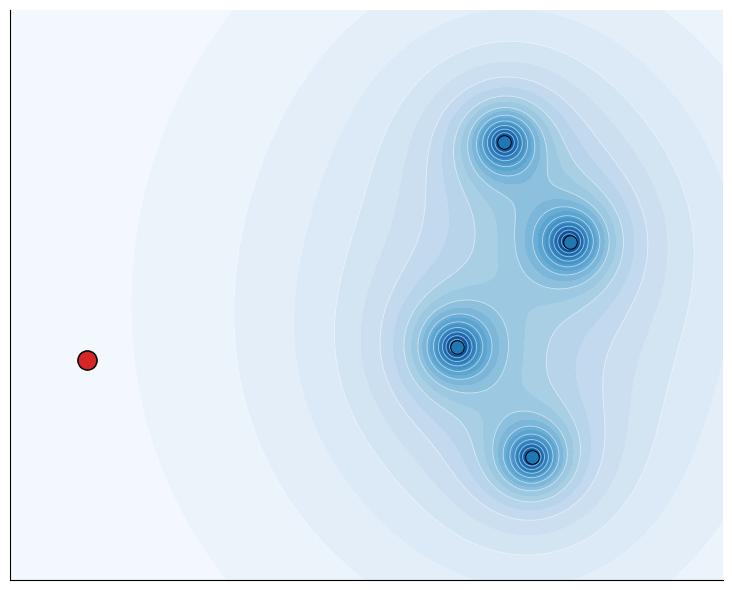

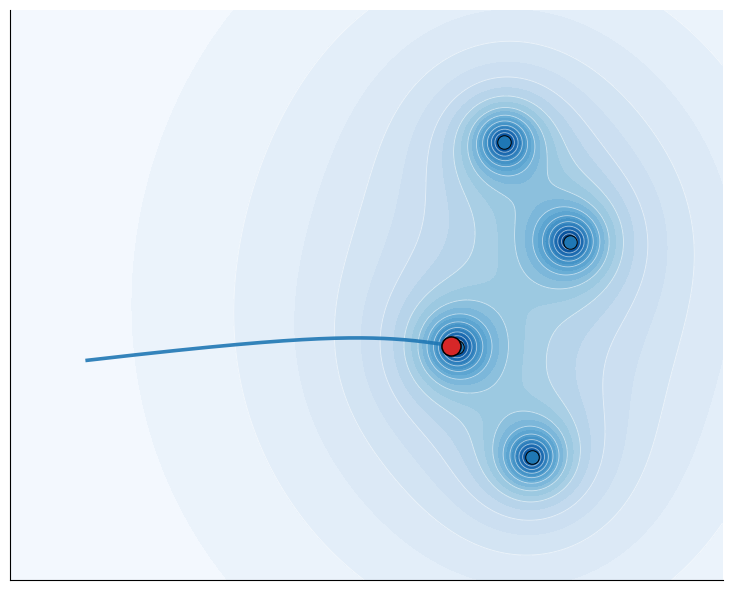

Number of source charges: 4
Number of simulated steps: 540
Initial position: [-2.35 -0.55]
Final position:   [ 0.70977226 -0.42640282]
Saved static image to: slide3_potential_initial.png
Saved animation GIF to: slide3_potential_motion.gif


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ============================================================
# Slide 3:
# Show the potential landscape created by fixed negative charges
# and animate the same positive particle moving on top of it.
#
# Dynamics:
#   dx/dt = mobility * F(x)
#
# Potential:
#   V(x) = sum_i k q_i / sqrt(||x-r_i||^2 + eps^2)
#
# Since q_i < 0, V is negative.
# For visualization we plot -V so deep attractive regions appear darker.
# ============================================================


# -----------------------------
# 1. Tunable settings
# -----------------------------
np.random.seed(7)

N_SOURCE_CHARGES = 4
SOURCE_SHAPE = "S"              # "S" or "triangle"

DT = 0.015
N_STEPS = 1200
MOBILITY = 0.55
K_COULOMB = 1.0
SOFTENING_FORCE = 0.14
SOFTENING_POTENTIAL = 0.12
MAX_SPEED = 2.0
CAPTURE_RADIUS = 0.08

X_LIM = (-3.0, 3.0)
Y_LIM = (-2.4, 2.4)

SOURCE_CENTER = np.array([1.25, 0.0])
START_POS = np.array([-2.35, -.55])

Q_SOURCE = -1.0

NX = 300
NY = 240

SAVE_INITIAL_PNG = True
SAVE_ANIMATION_GIF = True

INITIAL_PNG_PATH = "slide3_potential_initial.png"
ANIMATION_GIF_PATH = "slide3_potential_motion.gif"


# -----------------------------
# 2. Build source charges
# -----------------------------
def make_source_charges(shape="S", n=18, center=np.array([1.25, 0.0])):
    if shape == "S":
        t = np.linspace(-np.pi, np.pi, n)
        x = 0.55 * np.sin(1.05 * t)
        y = 1.35 * t / np.pi
        charges = np.stack([x, y], axis=1)
        charges += 0.035 * np.random.randn(n, 2)

    elif shape == "triangle":
        n1 = n // 3
        n2 = n // 3
        n3 = n - n1 - n2

        A = np.array([-0.65, -0.95])
        B = np.array([0.65, -0.95])
        C = np.array([0.0, 0.95])

        edge1 = np.linspace(A, B, n1, endpoint=False)
        edge2 = np.linspace(B, C, n2, endpoint=False)
        edge3 = np.linspace(C, A, n3, endpoint=False)

        charges = np.vstack([edge1, edge2, edge3])
        charges += 0.025 * np.random.randn(n, 2)

    else:
        raise ValueError("shape must be 'S' or 'triangle'")

    return charges + center[None, :]


source_pos = make_source_charges(
    shape=SOURCE_SHAPE,
    n=N_SOURCE_CHARGES,
    center=SOURCE_CENTER
)


# -----------------------------
# 3. Force on red positive particle
# -----------------------------
def force_on_positive_charge(x, source_positions):
    r = source_positions - x[None, :]
    dist2 = np.sum(r**2, axis=1) + SOFTENING_FORCE**2
    dist3 = dist2 ** 1.5
    forces = K_COULOMB * r / dist3[:, None]
    return np.sum(forces, axis=0)


def overdamped_step(x, source_positions, dt=DT):
    F = force_on_positive_charge(x, source_positions)
    v = MOBILITY * F

    speed = np.linalg.norm(v)
    if speed > MAX_SPEED:
        v = v / speed * MAX_SPEED

    return x + dt * v


# -----------------------------
# 4. Simulate trajectory
# -----------------------------
trajectory = [START_POS.copy()]
x = START_POS.copy()

for _ in range(N_STEPS):
    x_new = overdamped_step(x, source_pos, DT)
    trajectory.append(x_new.copy())
    x = x_new

    distances = np.linalg.norm(source_pos - x[None, :], axis=1)
    if np.min(distances) < CAPTURE_RADIUS:
        break

trajectory = np.array(trajectory)


# -----------------------------
# 5. Compute potential grid
# -----------------------------
def compute_potential_grid(source_positions,
                           q_source=-1.0,
                           k_coulomb=1.0,
                           eps=0.12,
                           xlim=(-3.0, 3.0),
                           ylim=(-2.4, 2.4),
                           nx=300,
                           ny=240):
    xs = np.linspace(xlim[0], xlim[1], nx)
    ys = np.linspace(ylim[0], ylim[1], ny)
    X, Y = np.meshgrid(xs, ys)

    V = np.zeros_like(X, dtype=float)

    for i in range(source_positions.shape[0]):
        dx = X - source_positions[i, 0]
        dy = Y - source_positions[i, 1]
        dist = np.sqrt(dx**2 + dy**2 + eps**2)
        V += k_coulomb * q_source / dist

    return X, Y, V


Xg, Yg, V = compute_potential_grid(
    source_positions=source_pos,
    q_source=Q_SOURCE,
    k_coulomb=K_COULOMB,
    eps=SOFTENING_POTENTIAL,
    xlim=X_LIM,
    ylim=Y_LIM,
    nx=NX,
    ny=NY
)

# Since V is negative, display -V so "stronger attraction" looks darker
V_display = -V


# -----------------------------
# 6. Common styling
# -----------------------------
def clean_axes(ax):
    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def draw_background(ax):
    ax.contourf(Xg, Yg, V_display, levels=30, cmap="Blues")
    ax.contour(
        Xg, Yg, V_display,
        levels=12,
        colors="white",
        linewidths=0.6,
        alpha=0.6
    )

    ax.scatter(
        source_pos[:, 0],
        source_pos[:, 1],
        s=95,
        c="tab:blue",
        edgecolor="black",
        linewidth=0.7,
        zorder=3
    )

    clean_axes(ax)


# -----------------------------
# 7. Static plot
# -----------------------------
def plot_initial_condition():
    fig, ax = plt.subplots(figsize=(8, 6))

    draw_background(ax)

    ax.scatter(
        START_POS[0],
        START_POS[1],
        s=190,
        c="tab:red",
        edgecolor="black",
        linewidth=1.1,
        zorder=4
    )

    plt.tight_layout()

    if SAVE_INITIAL_PNG:
        plt.savefig(INITIAL_PNG_PATH, dpi=300, bbox_inches="tight")

    plt.show()


plot_initial_condition()


# -----------------------------
# 8. Animation
# -----------------------------
def animate_charge_motion():
    fig, ax = plt.subplots(figsize=(8, 6))

    draw_background(ax)

    path_line, = ax.plot([], [], lw=2.6, alpha=0.9, zorder=4)

    pos_dot = ax.scatter(
        [],
        [],
        s=190,
        c="tab:red",
        edgecolor="black",
        linewidth=1.1,
        zorder=5
    )

    frame_ids = np.linspace(0, len(trajectory) - 1, 180).astype(int)

    def init():
        path_line.set_data([], [])
        pos_dot.set_offsets(np.array([[trajectory[0, 0], trajectory[0, 1]]]))
        return path_line, pos_dot

    def update(frame_idx):
        idx = frame_ids[frame_idx]

        path_line.set_data(
            trajectory[:idx + 1, 0],
            trajectory[:idx + 1, 1]
        )

        pos_dot.set_offsets(
            np.array([[trajectory[idx, 0], trajectory[idx, 1]]])
        )

        return path_line, pos_dot

    anim = FuncAnimation(
        fig,
        update,
        frames=len(frame_ids),
        init_func=init,
        interval=35,
        blit=True
    )

    plt.tight_layout()

    if SAVE_ANIMATION_GIF:
        anim.save(ANIMATION_GIF_PATH, writer=PillowWriter(fps=25))

    plt.show()

    return anim


anim = animate_charge_motion()


# -----------------------------
# 9. Print info
# -----------------------------
print(f"Number of source charges: {N_SOURCE_CHARGES}")
print(f"Number of simulated steps: {len(trajectory)}")
print(f"Initial position: {trajectory[0]}")
print(f"Final position:   {trajectory[-1]}")
print(f"Saved static image to: {INITIAL_PNG_PATH}")
print(f"Saved animation GIF to: {ANIMATION_GIF_PATH}")

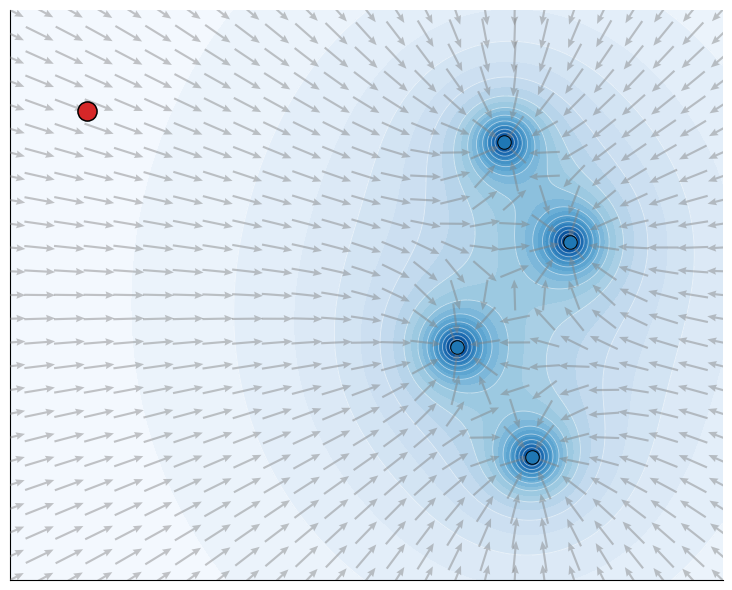

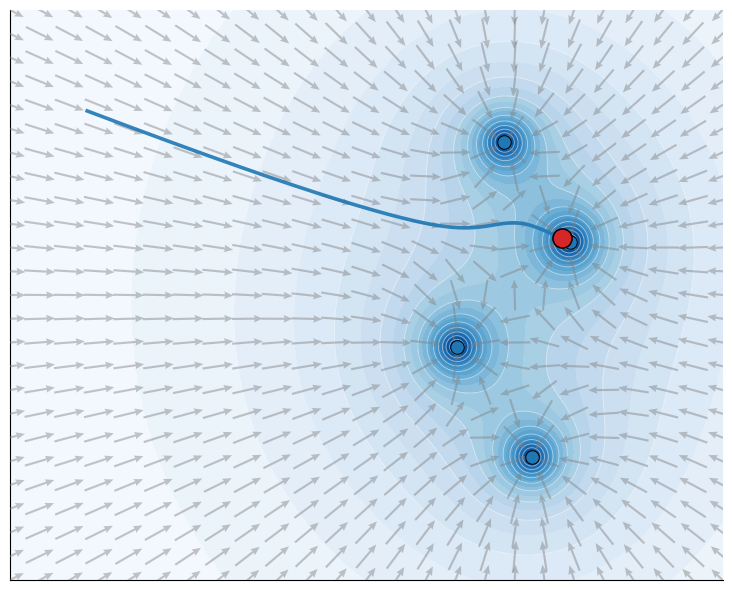

Number of source charges: 4
Number of simulated steps: 750
Initial position: [-2.35  1.55]
Final position:   [1.64887163 0.47735244]
Saved static image to: slide4_potential_force_initial.png
Saved animation GIF to: slide4_potential_force_motion.gif


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ============================================================
# Slide 4:
# Potential landscape + force field + moving red particle
#
# Background:
#   potential field phi(x)
#
# Arrows:
#   force field F(x) = -grad phi(x)
#
# Motion:
#   dx/dt = mobility * F(x)
#
# This version makes arrow size / alpha / thickness / length tunable.
# ============================================================


# -----------------------------
# 1. Tunable settings
# -----------------------------
np.random.seed(7)

# Source-charge configuration
N_SOURCE_CHARGES = 4          # tunable
SOURCE_SHAPE = "S"             # "S" or "triangle"
SOURCE_CENTER = np.array([1.25, 0.0])

# Red particle
START_POS = np.array([-2.35, 1.55])

# Dynamics
DT = 0.015
N_STEPS = 1200
MOBILITY = 0.55
K_COULOMB = 1.0
SOFTENING_FORCE = 0.14
SOFTENING_POTENTIAL = 0.12
MAX_SPEED = 2.0
CAPTURE_RADIUS = 0.08
Q_SOURCE = -1.0

# Plot limits
X_LIM = (-3.0, 3.0)
Y_LIM = (-2.4, 2.4)

# Potential grid resolution
NX = 300
NY = 240

# Arrow grid resolution
NQX = 25
NQY = 25

# Arrow appearance (fully tunable)
ARROW_COLOR = "grey"
ARROW_ALPHA = 0.45
ARROW_WIDTH = 0.003
ARROW_LENGTH = 0.26            # overall displayed arrow length in plot units
ARROW_HEADWIDTH = 3.5
ARROW_HEADLENGTH = 4.2
ARROW_HEADAXISLENGTH = 3.8
ARROW_NORMALIZE = True         # True = same length arrows, False = preserve magnitudes

# Saving
SAVE_INITIAL_PNG = True
SAVE_ANIMATION_GIF = True

INITIAL_PNG_PATH = "slide4_potential_force_initial.png"
ANIMATION_GIF_PATH = "slide4_potential_force_motion.gif"


# -----------------------------
# 2. Build source charges
# -----------------------------
def make_source_charges(shape="S", n=18, center=np.array([1.25, 0.0])):
    if shape == "S":
        t = np.linspace(-np.pi, np.pi, n)
        x = 0.55 * np.sin(1.05 * t)
        y = 1.35 * t / np.pi
        charges = np.stack([x, y], axis=1)
        charges += 0.035 * np.random.randn(n, 2)

    elif shape == "triangle":
        n1 = n // 3
        n2 = n // 3
        n3 = n - n1 - n2

        A = np.array([-0.65, -0.95])
        B = np.array([ 0.65, -0.95])
        C = np.array([ 0.00,  0.95])

        edge1 = np.linspace(A, B, n1, endpoint=False)
        edge2 = np.linspace(B, C, n2, endpoint=False)
        edge3 = np.linspace(C, A, n3, endpoint=False)

        charges = np.vstack([edge1, edge2, edge3])
        charges += 0.025 * np.random.randn(n, 2)

    else:
        raise ValueError("shape must be 'S' or 'triangle'")

    return charges + center[None, :]


source_pos = make_source_charges(
    shape=SOURCE_SHAPE,
    n=N_SOURCE_CHARGES,
    center=SOURCE_CENTER
)


# -----------------------------
# 3. Force on positive charge
# -----------------------------
def force_on_positive_charge(x, source_positions):
    """
    Total attractive force on a positive test charge at x
    due to fixed negative source charges.
    """
    r = source_positions - x[None, :]
    dist2 = np.sum(r**2, axis=1) + SOFTENING_FORCE**2
    dist3 = dist2 ** 1.5
    forces = K_COULOMB * r / dist3[:, None]
    return np.sum(forces, axis=0)


def overdamped_step(x, source_positions, dt=DT):
    """
    One Euler step of overdamped motion:
        dx/dt = mobility * F(x)
    """
    F = force_on_positive_charge(x, source_positions)
    v = MOBILITY * F

    speed = np.linalg.norm(v)
    if speed > MAX_SPEED:
        v = v / speed * MAX_SPEED

    return x + dt * v


# -----------------------------
# 4. Simulate trajectory
# -----------------------------
trajectory = [START_POS.copy()]
x = START_POS.copy()

for _ in range(N_STEPS):
    x_new = overdamped_step(x, source_pos, DT)
    trajectory.append(x_new.copy())
    x = x_new

    distances = np.linalg.norm(source_pos - x[None, :], axis=1)
    if np.min(distances) < CAPTURE_RADIUS:
        break

trajectory = np.array(trajectory)


# -----------------------------
# 5. Potential grid
# -----------------------------
def compute_potential_grid(source_positions,
                           q_source=-1.0,
                           k_coulomb=1.0,
                           eps=0.12,
                           xlim=(-3.0, 3.0),
                           ylim=(-2.4, 2.4),
                           nx=300,
                           ny=240):
    xs = np.linspace(xlim[0], xlim[1], nx)
    ys = np.linspace(ylim[0], ylim[1], ny)
    X, Y = np.meshgrid(xs, ys)

    phi = np.zeros_like(X, dtype=float)

    for i in range(source_positions.shape[0]):
        dx = X - source_positions[i, 0]
        dy = Y - source_positions[i, 1]
        dist = np.sqrt(dx**2 + dy**2 + eps**2)
        phi += k_coulomb * q_source / dist

    return X, Y, phi


Xg, Yg, phi = compute_potential_grid(
    source_positions=source_pos,
    q_source=Q_SOURCE,
    k_coulomb=K_COULOMB,
    eps=SOFTENING_POTENTIAL,
    xlim=X_LIM,
    ylim=Y_LIM,
    nx=NX,
    ny=NY
)

# For display only:
# negative charges produce negative phi,
# so plotting -phi makes strong attractive wells appear darker
phi_display = -phi


# -----------------------------
# 6. Force field grid for arrows
# -----------------------------
def compute_force_field_grid(source_positions,
                             xlim=(-3.0, 3.0),
                             ylim=(-2.4, 2.4),
                             nx=19,
                             ny=15,
                             normalize=True):
    xs = np.linspace(xlim[0], xlim[1], nx)
    ys = np.linspace(ylim[0], ylim[1], ny)
    X, Y = np.meshgrid(xs, ys)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(ny):
        for j in range(nx):
            pos = np.array([X[i, j], Y[i, j]])
            F = force_on_positive_charge(pos, source_positions)

            if normalize:
                nrm = np.linalg.norm(F)
                if nrm > 1e-10:
                    F = F / nrm

            U[i, j] = F[0]
            V[i, j] = F[1]

    return X, Y, U, V


Xq, Yq, Uq, Vq = compute_force_field_grid(
    source_positions=source_pos,
    xlim=X_LIM,
    ylim=Y_LIM,
    nx=NQX,
    ny=NQY,
    normalize=ARROW_NORMALIZE
)

# Rescale arrows explicitly so displayed length is tunable
Uq_plot = ARROW_LENGTH * Uq
Vq_plot = ARROW_LENGTH * Vq


# -----------------------------
# 7. Common styling
# -----------------------------
def clean_axes(ax):
    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def draw_background(ax):
    # potential background
    ax.contourf(Xg, Yg, phi_display, levels=30, cmap="Blues")
    ax.contour(
        Xg, Yg, phi_display,
        levels=12,
        colors="white",
        linewidths=0.6,
        alpha=0.55
    )

    # source charges
    ax.scatter(
        source_pos[:, 0],
        source_pos[:, 1],
        s=95,
        c="tab:blue",
        edgecolor="black",
        linewidth=0.7,
        zorder=4
    )

    # force field arrows
    ax.quiver(
        Xq, Yq, Uq_plot, Vq_plot,
        color=ARROW_COLOR,
        alpha=ARROW_ALPHA,
        pivot="mid",
        angles="xy",
        scale_units="xy",
        scale=1,
        width=ARROW_WIDTH,
        headwidth=ARROW_HEADWIDTH,
        headlength=ARROW_HEADLENGTH,
        headaxislength=ARROW_HEADAXISLENGTH,
        zorder=3
    )

    clean_axes(ax)


# -----------------------------
# 8. Static plot
# -----------------------------
def plot_initial_condition():
    fig, ax = plt.subplots(figsize=(8, 6))

    draw_background(ax)

    ax.scatter(
        START_POS[0],
        START_POS[1],
        s=190,
        c="tab:red",
        edgecolor="black",
        linewidth=1.1,
        zorder=6
    )

    plt.tight_layout()

    if SAVE_INITIAL_PNG:
        plt.savefig(INITIAL_PNG_PATH, dpi=300, bbox_inches="tight")

    plt.show()


plot_initial_condition()


# -----------------------------
# 9. Animation
# -----------------------------
def animate_charge_motion():
    fig, ax = plt.subplots(figsize=(8, 6))

    draw_background(ax)

    path_line, = ax.plot([], [], lw=2.6, alpha=0.9, zorder=6)

    pos_dot = ax.scatter(
        [],
        [],
        s=190,
        c="tab:red",
        edgecolor="black",
        linewidth=1.1,
        zorder=7
    )

    frame_ids = np.linspace(0, len(trajectory) - 1, 180).astype(int)

    def init():
        path_line.set_data([], [])
        pos_dot.set_offsets(np.array([[trajectory[0, 0], trajectory[0, 1]]]))
        return path_line, pos_dot

    def update(frame_idx):
        idx = frame_ids[frame_idx]

        path_line.set_data(
            trajectory[:idx + 1, 0],
            trajectory[:idx + 1, 1]
        )

        pos_dot.set_offsets(
            np.array([[trajectory[idx, 0], trajectory[idx, 1]]])
        )

        return path_line, pos_dot

    anim = FuncAnimation(
        fig,
        update,
        frames=len(frame_ids),
        init_func=init,
        interval=35,
        blit=True
    )

    plt.tight_layout()

    if SAVE_ANIMATION_GIF:
        anim.save(ANIMATION_GIF_PATH, writer=PillowWriter(fps=25))

    plt.show()

    return anim


anim = animate_charge_motion()


# -----------------------------
# 10. Print info
# -----------------------------
print(f"Number of source charges: {N_SOURCE_CHARGES}")
print(f"Number of simulated steps: {len(trajectory)}")
print(f"Initial position: {trajectory[0]}")
print(f"Final position:   {trajectory[-1]}")
print(f"Saved static image to: {INITIAL_PNG_PATH}")
print(f"Saved animation GIF to: {ANIMATION_GIF_PATH}")

# Reverse ODE

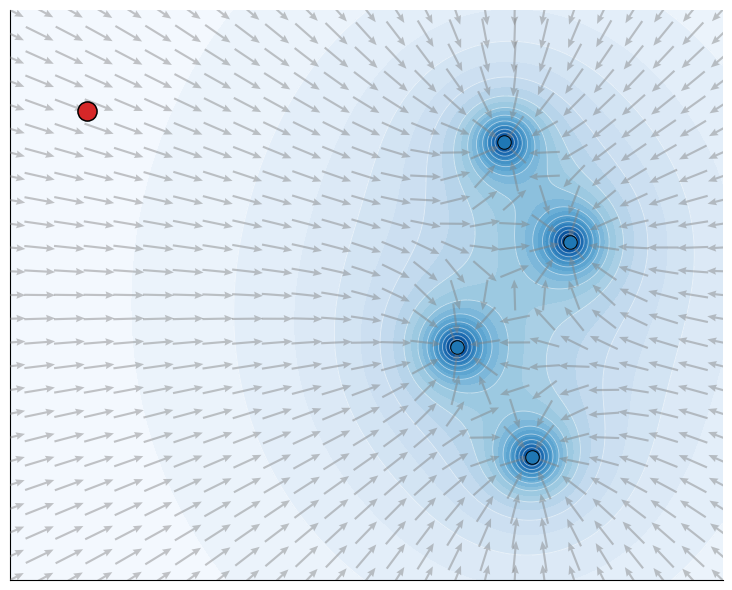

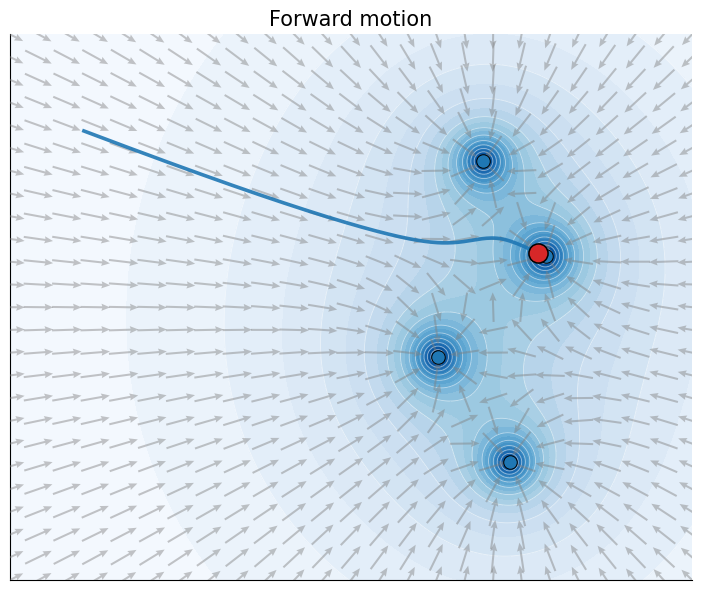

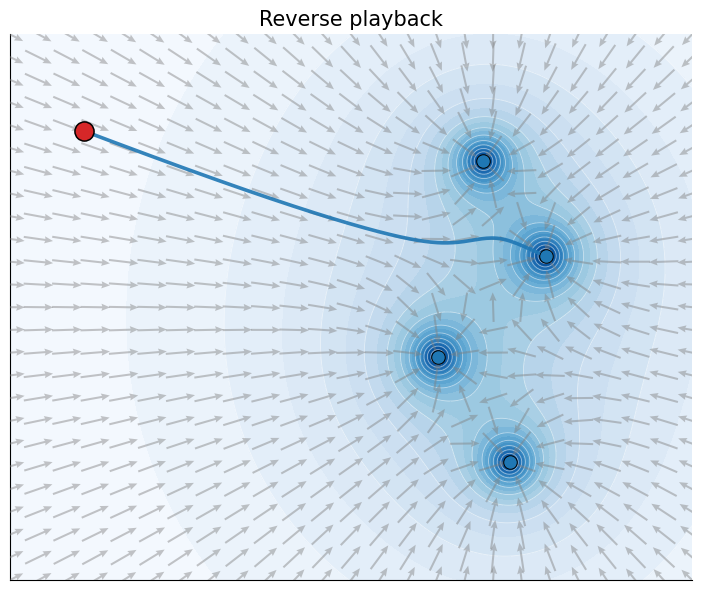

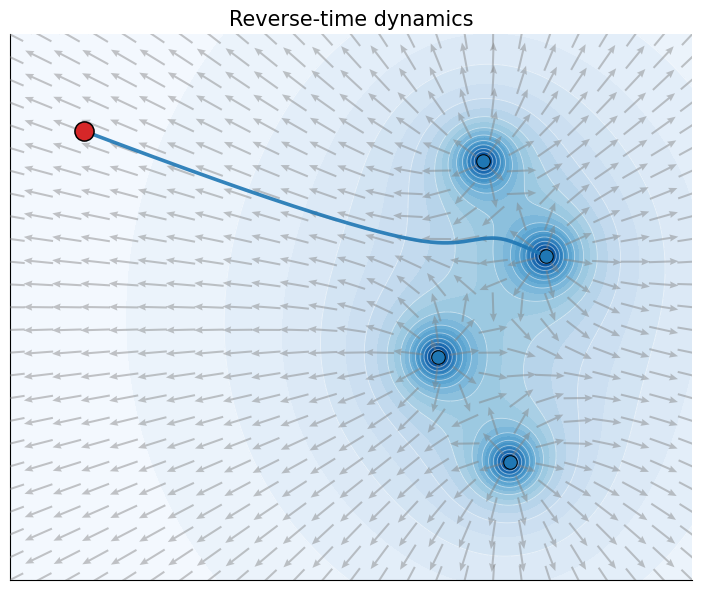

Number of source charges: 4
Number of simulated steps: 750
Initial position: [-2.35  1.55]
Final position:   [1.64887163 0.47735244]
Saved static image to: slide4_potential_force_initial.png
Saved forward animation to: slide4_potential_force_motion_forward.gif
Saved reverse playback animation to: slide4_potential_force_motion_reverse.gif
Saved reverse-dynamics animation to: slide4_potential_force_motion_reverse_dynamics.gif


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ============================================================
# Potential landscape + force field + moving red particle
# with BOTH forward and reverse animations.
#
# Reverse options:
#   1) reverse playback only  -> particle moves backward, arrows unchanged
#   2) reverse dynamics       -> particle moves backward, arrows flipped
# ============================================================


# -----------------------------
# 1. Tunable settings
# -----------------------------
np.random.seed(7)

# Source-charge configuration
N_SOURCE_CHARGES = 4
SOURCE_SHAPE = "S"             # "S" or "triangle"
SOURCE_CENTER = np.array([1.25, 0.0])

# Red particle
START_POS = np.array([-2.35, 1.55])

# Dynamics
DT = 0.015
N_STEPS = 1200
MOBILITY = 0.55
K_COULOMB = 1.0
SOFTENING_FORCE = 0.14
SOFTENING_POTENTIAL = 0.12
MAX_SPEED = 2.0
CAPTURE_RADIUS = 0.08
Q_SOURCE = -1.0

# Plot limits
X_LIM = (-3.0, 3.0)
Y_LIM = (-2.4, 2.4)

# Potential grid resolution
NX = 300
NY = 240

# Arrow grid resolution
NQX = 25
NQY = 25

# Arrow appearance
ARROW_COLOR = "grey"
ARROW_ALPHA = 0.45
ARROW_WIDTH = 0.003
ARROW_LENGTH = 0.26
ARROW_HEADWIDTH = 3.5
ARROW_HEADLENGTH = 4.2
ARROW_HEADAXISLENGTH = 3.8
ARROW_NORMALIZE = True

# Animation frame count
N_FRAMES = 180

# Saving
SAVE_INITIAL_PNG = True
SAVE_FORWARD_ANIMATION_GIF = True
SAVE_REVERSE_ANIMATION_GIF = True
SAVE_REVERSE_DYNAMICS_GIF = True

INITIAL_PNG_PATH = "slide4_potential_force_initial.png"
FORWARD_GIF_PATH = "slide4_potential_force_motion_forward.gif"
REVERSE_GIF_PATH = "slide4_potential_force_motion_reverse.gif"
REVERSE_DYNAMICS_GIF_PATH = "slide4_potential_force_motion_reverse_dynamics.gif"


# -----------------------------
# 2. Build source charges
# -----------------------------
def make_source_charges(shape="S", n=18, center=np.array([1.25, 0.0])):
    if shape == "S":
        t = np.linspace(-np.pi, np.pi, n)
        x = 0.55 * np.sin(1.05 * t)
        y = 1.35 * t / np.pi
        charges = np.stack([x, y], axis=1)
        charges += 0.035 * np.random.randn(n, 2)

    elif shape == "triangle":
        n1 = n // 3
        n2 = n // 3
        n3 = n - n1 - n2

        A = np.array([-0.65, -0.95])
        B = np.array([ 0.65, -0.95])
        C = np.array([ 0.00,  0.95])

        edge1 = np.linspace(A, B, n1, endpoint=False)
        edge2 = np.linspace(B, C, n2, endpoint=False)
        edge3 = np.linspace(C, A, n3, endpoint=False)

        charges = np.vstack([edge1, edge2, edge3])
        charges += 0.025 * np.random.randn(n, 2)

    else:
        raise ValueError("shape must be 'S' or 'triangle'")

    return charges + center[None, :]


source_pos = make_source_charges(
    shape=SOURCE_SHAPE,
    n=N_SOURCE_CHARGES,
    center=SOURCE_CENTER
)


# -----------------------------
# 3. Force on positive charge
# -----------------------------
def force_on_positive_charge(x, source_positions):
    """
    Total attractive force on a positive test charge at x
    due to fixed negative source charges.
    """
    r = source_positions - x[None, :]
    dist2 = np.sum(r**2, axis=1) + SOFTENING_FORCE**2
    dist3 = dist2 ** 1.5
    forces = K_COULOMB * r / dist3[:, None]
    return np.sum(forces, axis=0)


def overdamped_step(x, source_positions, dt=DT):
    """
    One Euler step of overdamped motion:
        dx/dt = mobility * F(x)
    """
    F = force_on_positive_charge(x, source_positions)
    v = MOBILITY * F

    speed = np.linalg.norm(v)
    if speed > MAX_SPEED:
        v = v / speed * MAX_SPEED

    return x + dt * v


# -----------------------------
# 4. Simulate forward trajectory
# -----------------------------
trajectory = [START_POS.copy()]
x = START_POS.copy()

for _ in range(N_STEPS):
    x_new = overdamped_step(x, source_pos, DT)
    trajectory.append(x_new.copy())
    x = x_new

    distances = np.linalg.norm(source_pos - x[None, :], axis=1)
    if np.min(distances) < CAPTURE_RADIUS:
        break

trajectory = np.array(trajectory)
reverse_trajectory = trajectory[::-1].copy()


# -----------------------------
# 5. Potential grid
# -----------------------------
def compute_potential_grid(source_positions,
                           q_source=-1.0,
                           k_coulomb=1.0,
                           eps=0.12,
                           xlim=(-3.0, 3.0),
                           ylim=(-2.4, 2.4),
                           nx=300,
                           ny=240):
    xs = np.linspace(xlim[0], xlim[1], nx)
    ys = np.linspace(ylim[0], ylim[1], ny)
    X, Y = np.meshgrid(xs, ys)

    phi = np.zeros_like(X, dtype=float)

    for i in range(source_positions.shape[0]):
        dx = X - source_positions[i, 0]
        dy = Y - source_positions[i, 1]
        dist = np.sqrt(dx**2 + dy**2 + eps**2)
        phi += k_coulomb * q_source / dist

    return X, Y, phi


Xg, Yg, phi = compute_potential_grid(
    source_positions=source_pos,
    q_source=Q_SOURCE,
    k_coulomb=K_COULOMB,
    eps=SOFTENING_POTENTIAL,
    xlim=X_LIM,
    ylim=Y_LIM,
    nx=NX,
    ny=NY
)

# For display only:
# negative charges produce negative phi,
# so plotting -phi makes strong attractive wells appear darker
phi_display = -phi


# -----------------------------
# 6. Force field grid for arrows
# -----------------------------
def compute_force_field_grid(source_positions,
                             xlim=(-3.0, 3.0),
                             ylim=(-2.4, 2.4),
                             nx=19,
                             ny=15,
                             normalize=True):
    xs = np.linspace(xlim[0], xlim[1], nx)
    ys = np.linspace(ylim[0], ylim[1], ny)
    X, Y = np.meshgrid(xs, ys)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(ny):
        for j in range(nx):
            pos = np.array([X[i, j], Y[i, j]])
            F = force_on_positive_charge(pos, source_positions)

            if normalize:
                nrm = np.linalg.norm(F)
                if nrm > 1e-10:
                    F = F / nrm

            U[i, j] = F[0]
            V[i, j] = F[1]

    return X, Y, U, V


Xq, Yq, Uq, Vq = compute_force_field_grid(
    source_positions=source_pos,
    xlim=X_LIM,
    ylim=Y_LIM,
    nx=NQX,
    ny=NQY,
    normalize=ARROW_NORMALIZE
)

# Rescale arrows explicitly so displayed length is tunable
Uq_plot = ARROW_LENGTH * Uq
Vq_plot = ARROW_LENGTH * Vq


# -----------------------------
# 7. Common styling
# -----------------------------
def clean_axes(ax):
    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def draw_background(ax, flip_field=False):
    # potential background
    ax.contourf(Xg, Yg, phi_display, levels=30, cmap="Blues")
    ax.contour(
        Xg, Yg, phi_display,
        levels=12,
        colors="white",
        linewidths=0.6,
        alpha=0.55
    )

    # source charges
    ax.scatter(
        source_pos[:, 0],
        source_pos[:, 1],
        s=95,
        c="tab:blue",
        edgecolor="black",
        linewidth=0.7,
        zorder=4
    )

    # choose forward or reverse arrows
    sign = -1 if flip_field else 1

    # force field arrows
    ax.quiver(
        Xq, Yq, sign * Uq_plot, sign * Vq_plot,
        color=ARROW_COLOR,
        alpha=ARROW_ALPHA,
        pivot="mid",
        angles="xy",
        scale_units="xy",
        scale=1,
        width=ARROW_WIDTH,
        headwidth=ARROW_HEADWIDTH,
        headlength=ARROW_HEADLENGTH,
        headaxislength=ARROW_HEADAXISLENGTH,
        zorder=3
    )

    clean_axes(ax)


# -----------------------------
# 8. Static plot
# -----------------------------
def plot_initial_condition():
    fig, ax = plt.subplots(figsize=(8, 6))

    draw_background(ax, flip_field=False)

    ax.scatter(
        START_POS[0],
        START_POS[1],
        s=190,
        c="tab:red",
        edgecolor="black",
        linewidth=1.1,
        zorder=6
    )

    plt.tight_layout()

    if SAVE_INITIAL_PNG:
        plt.savefig(INITIAL_PNG_PATH, dpi=300, bbox_inches="tight")

    plt.show()


plot_initial_condition()


# -----------------------------
# 9. Generic animation function
# -----------------------------
def animate_charge_motion(traj,
                          gif_path,
                          flip_field=False,
                          title=None):
    """
    traj: trajectory to animate
    gif_path: output gif path
    flip_field: if True, flip arrows to show reverse-time field
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    draw_background(ax, flip_field=flip_field)

    if title is not None:
        ax.set_title(title, fontsize=15)

    path_line, = ax.plot([], [], lw=2.6, alpha=0.9, zorder=6)

    pos_dot = ax.scatter(
        [],
        [],
        s=190,
        c="tab:red",
        edgecolor="black",
        linewidth=1.1,
        zorder=7
    )

    frame_ids = np.linspace(0, len(traj) - 1, N_FRAMES).astype(int)

    def init():
        path_line.set_data([], [])
        pos_dot.set_offsets(np.array([[traj[0, 0], traj[0, 1]]]))
        return path_line, pos_dot

    def update(frame_idx):
        idx = frame_ids[frame_idx]

        path_line.set_data(
            traj[:idx + 1, 0],
            traj[:idx + 1, 1]
        )

        pos_dot.set_offsets(
            np.array([[traj[idx, 0], traj[idx, 1]]])
        )

        return path_line, pos_dot

    anim = FuncAnimation(
        fig,
        update,
        frames=len(frame_ids),
        init_func=init,
        interval=35,
        blit=True
    )

    plt.tight_layout()
    anim.save(gif_path, writer=PillowWriter(fps=25))
    plt.show()

    return anim


# -----------------------------
# 10. Create animations
# -----------------------------
if SAVE_FORWARD_ANIMATION_GIF:
    anim_forward = animate_charge_motion(
        traj=trajectory,
        gif_path=FORWARD_GIF_PATH,
        flip_field=False,
        title="Forward motion"
    )

if SAVE_REVERSE_ANIMATION_GIF:
    # same arrows, reverse playback
    anim_reverse = animate_charge_motion(
        traj=reverse_trajectory,
        gif_path=REVERSE_GIF_PATH,
        flip_field=False,
        title="Reverse playback"
    )

if SAVE_REVERSE_DYNAMICS_GIF:
    # flipped arrows, reverse playback
    anim_reverse_dynamics = animate_charge_motion(
        traj=reverse_trajectory,
        gif_path=REVERSE_DYNAMICS_GIF_PATH,
        flip_field=True,
        title="Reverse-time dynamics"
    )


# -----------------------------
# 11. Print info
# -----------------------------
print(f"Number of source charges: {N_SOURCE_CHARGES}")
print(f"Number of simulated steps: {len(trajectory)}")
print(f"Initial position: {trajectory[0]}")
print(f"Final position:   {trajectory[-1]}")
print(f"Saved static image to: {INITIAL_PNG_PATH}")

if SAVE_FORWARD_ANIMATION_GIF:
    print(f"Saved forward animation to: {FORWARD_GIF_PATH}")

if SAVE_REVERSE_ANIMATION_GIF:
    print(f"Saved reverse playback animation to: {REVERSE_GIF_PATH}")

if SAVE_REVERSE_DYNAMICS_GIF:
    print(f"Saved reverse-dynamics animation to: {REVERSE_DYNAMICS_GIF_PATH}")